In [3]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba, compute_all_distances_batch, adc_distances_all_optimized  



# Dataset parameters
dataset_name = 'GIST'
sampling_method = 'random'
train_size_ratio = 0.1
k = 100  # Number of nearest neighbors

# PQ parameters
nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = 8  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer
crop = True
crop_len = 64

# root = "mnthdd"
root = "data"

print("Loading GIST dataset...")
# Loading the GIST dataset
db = np.array(read_fvecs(f'/{root}/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs(f'/{root}/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))




Loading GIST dataset...
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [4]:
if crop:
    db = db[:, :crop_len]
    qr = qr[:, :crop_len]

nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
db = db.astype(np.float32)
qr = qr.astype(np.float32)

# Sample training data if specified
if sampling_method == 'random':
    train_size = int(nb * train_size_ratio)
    train_indices = np.random.choice(nb, train_size, replace=False)
    train_data = db[train_indices]
    print(f"Training on {train_size} vectors ({train_size_ratio:.1%} of database)")
else:
    train_data = db
    print("Training on full database")

# Setup Product Quantizer
print(f"\nSetting up Product Quantizer...")
print(f"Parameters: {n_subquantizers} subquantizers, {nbits} bits each")
print(f"Compression: {dim*4} bytes -> {n_subquantizers} bytes per vector")


Database shape: (1000000, 64)
Query shape: (1000, 64)
Dimension: 64
Training on 100000 vectors (10.0% of database)

Setting up Product Quantizer...
Parameters: 8 subquantizers, 8 bits each
Compression: 256 bytes -> 8 bytes per vector


In [5]:
opq = faiss.OPQMatrix(dim, n_subquantizers)
pq = faiss.IndexPQ(dim, n_subquantizers, nbits)

index = faiss.IndexPreTransform(opq, pq)

start = time.time()
index.train(train_data)
train_time = time.time() - start
print(f"Training completed in {train_time:.2f} seconds")

Training completed in 5.55 seconds


In [6]:
# Encode database vectors
print("Encoding database vectors...")
start_time = time.time()
codes = index.sa_encode(db)
encoding_time = time.time() - start_time
print(f"Encoding completed in {encoding_time:.2f} seconds")
print(f"Codes shape: {codes.shape}")


Encoding database vectors...
Encoding completed in 0.15 seconds
Codes shape: (1000000, 8)


In [7]:
# Compute distance tables with optimization
print("Computing distance tables (optimized)...")
start_time = time.time()

inner = faiss.downcast_index(index.index)
qr_opq = opq.apply_py(qr)
# Get centroids from trained PQ
centroids = faiss.vector_to_array(inner.pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)

# Choose computation method based on dataset size
if nq > 1000:
    print("Using multi-threaded computation...")
    dis_tables = compute_distance_tables_threaded(qr_opq, centroids, n_subquantizers, ksub, dim)
else:
    print("Using vectorized computation...")
    dis_tables = compute_distance_tables_vectorized(qr_opq, centroids, n_subquantizers, ksub, dim)

distance_table_time = time.time() - start_time
print(f"Distance tables computed in {distance_table_time:.2f} seconds")


Computing distance tables (optimized)...
Using vectorized computation...
Distance tables computed in 0.08 seconds


In [13]:
sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)

qr_sample = qr[q_idx]
db_sample = db[db_idx]


# ADC distances for sampled subset
t0 = time.time()
adc_sample = adc_distances_batch_numba(
    dis_tables[q_idx], codes[db_idx], n_subquantizers
)
adc_time = time.time() - t0

print('adc time:', adc_time)

adc time: 0.02594733238220215


In [14]:
adc_sample

array([[0.109  , 0.07366, 0.13048, ..., 0.31537, 0.05981, 0.16164],
       [0.09333, 0.08158, 0.11783, ..., 0.33259, 0.0948 , 0.17825],
       [0.04683, 0.08574, 0.1952 , ..., 0.3954 , 0.0242 , 0.20895],
       ...,
       [0.12669, 0.10099, 0.11945, ..., 0.27389, 0.09779, 0.15654],
       [0.12734, 0.07   , 0.14364, ..., 0.27296, 0.05052, 0.13525],
       [0.13289, 0.06249, 0.12179, ..., 0.28431, 0.08634, 0.15075]],
      dtype=float32)

In [15]:

# Exact distances with cdist
t0 = time.time()
exact_sample = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0


In [16]:
exact_sample 

array([[0.11472, 0.07281, 0.16358, ..., 0.38307, 0.05519, 0.1874 ],
       [0.09183, 0.08877, 0.15939, ..., 0.40942, 0.08826, 0.20118],
       [0.04887, 0.08332, 0.23677, ..., 0.47303, 0.02302, 0.22482],
       ...,
       [0.13113, 0.10187, 0.15032, ..., 0.36768, 0.09703, 0.19072],
       [0.13107, 0.07526, 0.17697, ..., 0.35448, 0.05417, 0.15482],
       [0.14167, 0.06536, 0.14412, ..., 0.36141, 0.083  , 0.17826]],
      dtype=float32)

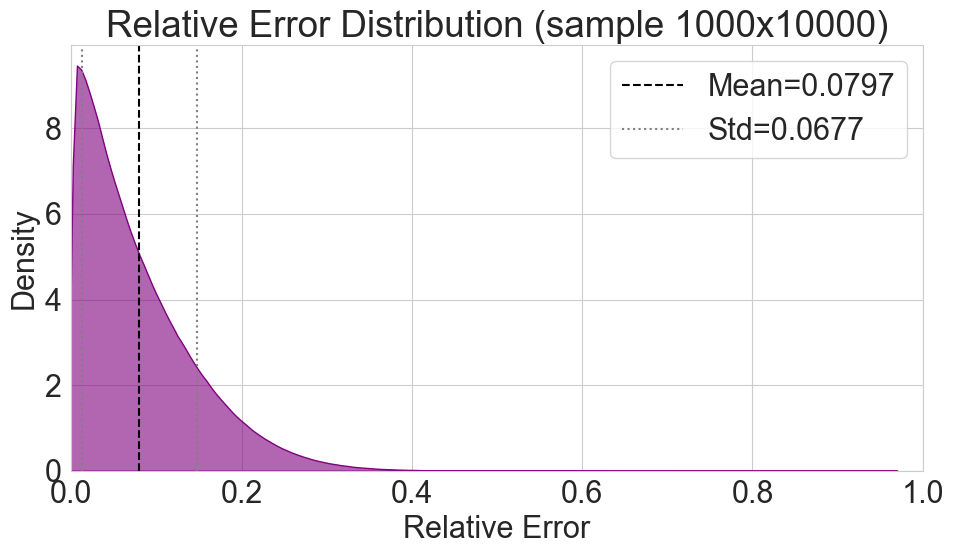

[cdist] sample 1000 queries x 10000 DB: 0.429s
Mean relative error=0.079690, Std=0.067666


In [17]:
plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")

# Relative errors
rel_error = np.abs(adc_sample - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile(f'/{root}/cpanourg/2-hdvc/results/opq/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0,1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [18]:

summary = {
    "method": "OPQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": len(db_idx),
    "dim": dim,
    "n_subquantizers": n_subquantizers,
    "nbits": nbits,
    "bits_per_vector": n_subquantizers * nbits,
    # "k": k,
    "train_ratio": train_size_ratio,
    "train_size": train_size,
    "train_time_s": float(train_time),
    "encoding_time_s": float(encoding_time),
    "distance_table_time_s": float(distance_table_time),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(adc_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}
csv_path=f"/{root}/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)


In [19]:
import pandas as pd

pd.read_csv(f"/{root}/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,nbits,bits_per_vector,train_ratio,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,GIST,1000,1000000,10000,64,8,8,64,0.1,100000,0.6456,0.0985,0.0632,0.4157,0.8987,0.1080,0.0895
1,OPQ,GIST,1000,1000000,10000,64,8,8,64,0.1,100000,5.5501,0.1462,0.0846,0.4295,0.0259,0.0797,0.0677
